# Vehicle Detection and Classification using YOLOv8
**Team Members:** Aragya Goyal and Olivia Sobek  
**Dataset:** [Link to Dataset](https://www.kaggle.com/datasets/barkataliarbab/vehicles-openimages-dataset-416416/data)  
**Model:** YOLOv8s - Finetuned via transfer learning

## 1. Setup and Installation

In [3]:
# Import Packages
import os
import shutil
import kagglehub
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from ultralytics import YOLO

# Define Globals
IMG_W, IMG_H = 416, 416
CLASS_NAMES = {0: "Ambulance", 1: "Bus", 2: "Car", 3: "Motorcycle", 4: "Truck"}

## 2. Download Dataset from Kaggle

In [4]:
# Use kagglehub to download the dataset
cache_path = kagglehub.dataset_download('barkataliarbab/vehicles-openimages-dataset-416416')
print("Downloaded to:", cache_path)

Downloaded to: C:\Users\agoya\.cache\kagglehub\datasets\barkataliarbab\vehicles-openimages-dataset-416416\versions\1


## 3. Copy files to local workspace and make YOLO labels

In [5]:
# Define dataset path and splits
dataset_root = "./dataset"
split_names = ["train", "valid", "test"]

# Copy the raw data
if os.path.exists(dataset_root):
    shutil.rmtree(dataset_root)

for split in split_names:
    src = os.path.join(cache_path, split)
    dst = os.path.join(dataset_root, split)
    shutil.copytree(src, dst)
    print(f"Copied {split} images: {len(os.listdir(dst))} files")

# Print break
print()

# Rename the files and reorganize
for split in split_names:
    # Get annotation file path
    split_dir = os.path.join(dataset_root, split)
    ann_path = os.path.join(split_dir, "_annotations.txt")

    # Create image and label folders
    img_dir = os.path.join(split_dir, "images")
    lbl_dir = os.path.join(split_dir, "labels")
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    # Parse the annotation file
    annotations = {}
    with open(ann_path, "r") as ann_file:
        for line in ann_file:
            # Get file names and bounding boxes with classifications
            parts = line.strip().split()
            
            # Parse through parts
            filename = parts[0]
            boxes = []
            for box_str in parts[1:]:
                x1, y1, x2, y2, cls_id = map(int, box_str.split(","))
                boxes.append((x1, y1, x2, y2, cls_id))
            
            # Add to dictionary
            annotations[filename] = boxes
    
    # Rename, move, and create labels
    count = 0
    for idx, (old_filename, boxes) in enumerate(sorted(annotations.items()), start=1):
        # Get old image path
        old_img_path = os.path.join(split_dir, old_filename)

        # Create new name for file based on part of the split and the id
        ext = os.path.splitext(old_filename)[1]
        new_basename = f"{split}_{idx:04d}"
        new_img_name = new_basename + ext

        # Move image into new directory with new name
        os.rename(old_img_path, os.path.join(img_dir, new_img_name))

        # Convert to YOLO format and write label file
        yolo_lines = []
        for (x1, y1, x2, y2, cls_id) in boxes:
            cx = ((x1 + x2) / 2) / IMG_W
            cy = ((y1 + y2) / 2) / IMG_H
            w = (x2 - x1) / IMG_W
            h = (y2 - y1) / IMG_H
            yolo_lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        with open(os.path.join(lbl_dir, new_basename + ".txt"), "w") as f:
            f.write("\n".join(yolo_lines) + "\n")

        count += 1

    print(f"{split}: {count} images -> images/ + labels/")

Copied train images: 880 files
Copied valid images: 252 files
Copied test images: 128 files

train: 878 images -> images/ + labels/
valid: 250 images -> images/ + labels/
test: 126 images -> images/ + labels/


## 4. Class Distribution Analysis

In [6]:
# Create counter for all counts and dictionary for per split
all_counts = Counter()
split_data = {}

# Loop through the splits
for split in split_names:
    # Get label directory per split
    lbl_dir = os.path.join(dataset_root, split, "labels")
    
    # Initialize class_id counts and total counts
    counts = Counter()
    total = 0

    for label_file in os.listdir(lbl_dir):
        # Check if file is a txt (should be) - skip if not
        if not label_file.endswith(".txt"):
            continue
        # Open the .txt label file
        with open(os.path.join(lbl_dir, label_file), "r") as file:
            # Go through each label
            for line in file:
                # Parse the label
                parts = line.strip().split()
                if len(parts) >= 5:
                    # First part of label is class id
                    class_id = int(parts[0])
                    counts[class_id] += 1
                    total += 1

    # Save to split data and overall all counts
    split_data[split] = (counts, total)
    all_counts += counts

    # Print per split information
    n_imgs = len([file for file in os.listdir(os.path.join(dataset_root, split, "images")) if not file.endswith(".txt")])
    print(f"{split}: {n_imgs} images, {total} bounding boxes")
    for class_id in sorted(CLASS_NAMES.keys()):
        count = counts.get(class_id, 0)
        percent = (count / total * 100)
        print(f"  {CLASS_NAMES[class_id]:>12s}: {count} ({percent}%)")

train: 878 images, 1676 bounding boxes
     Ambulance: 170 (10.143198090692124%)
           Bus: 198 (11.813842482100238%)
           Car: 914 (54.534606205250604%)
    Motorcycle: 202 (12.052505966587113%)
         Truck: 192 (11.455847255369928%)
valid: 250 images, 454 bounding boxes
     Ambulance: 64 (14.096916299559473%)
           Bus: 46 (10.13215859030837%)
           Car: 238 (52.42290748898678%)
    Motorcycle: 46 (10.13215859030837%)
         Truck: 60 (13.215859030837004%)
test: 126 images, 258 bounding boxes
     Ambulance: 18 (6.976744186046512%)
           Bus: 38 (14.728682170542637%)
           Car: 150 (58.139534883720934%)
    Motorcycle: 32 (12.4031007751938%)
         Truck: 20 (7.751937984496124%)


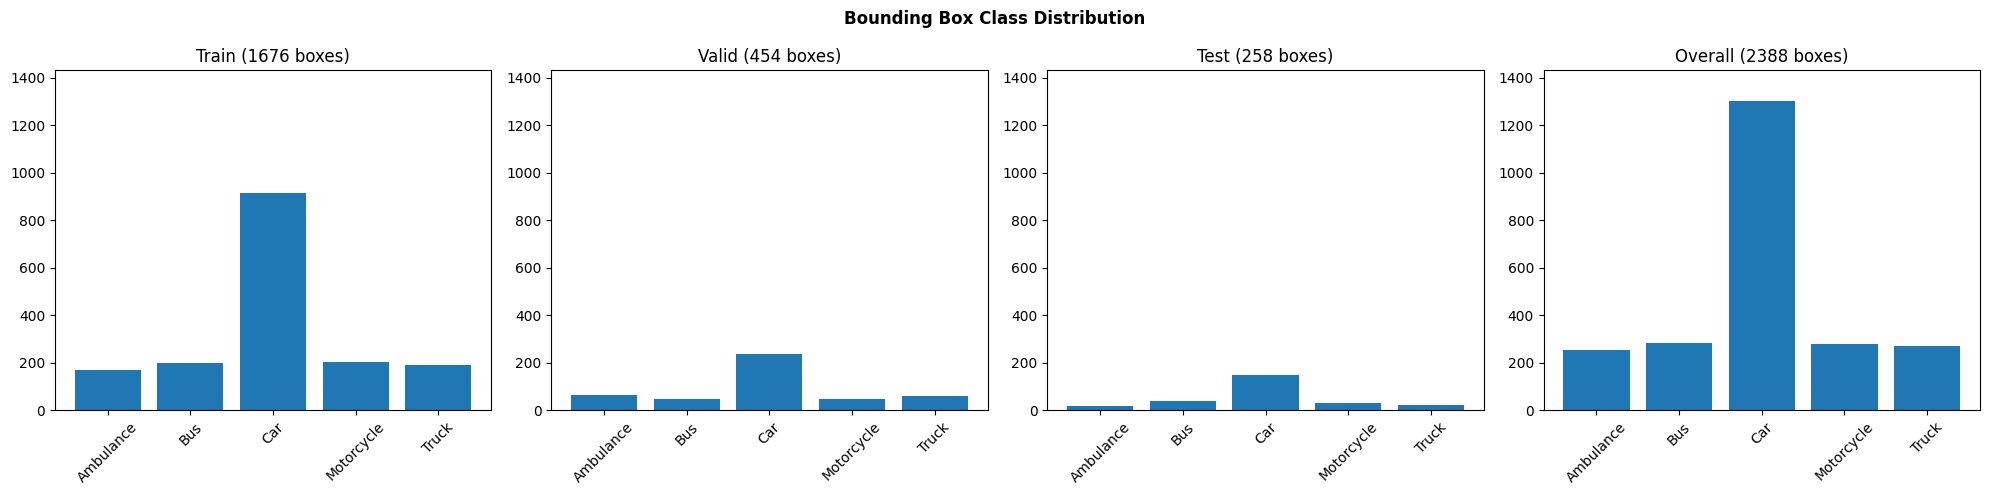

In [7]:
# Prepare for plotting
labels = list(CLASS_NAMES.values())
max_count = max(all_counts.values())
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot each split
for idx, (split, (counts, total)) in enumerate(split_data.items()):
    values = [counts.get(i, 0) for i in range(len(CLASS_NAMES))]
    axes[idx].bar(labels, values)
    axes[idx].set_title(f"{split.capitalize()} ({total} boxes)")
    axes[idx].set_ylim(0, max_count * 1.1)
    axes[idx].tick_params(axis="x", rotation=45)

# Plot overall
total_all = sum(all_counts.values())
values = [all_counts.get(i, 0) for i in range(len(CLASS_NAMES))]
axes[3].bar(labels, values)
axes[3].set_title(f"Overall ({total_all} boxes)")
axes[3].set_ylim(0, max(values) * 1.1)
axes[3].tick_params(axis="x", rotation=45)

plt.suptitle("Bounding Box Class Distribution", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Sample Image Visualization

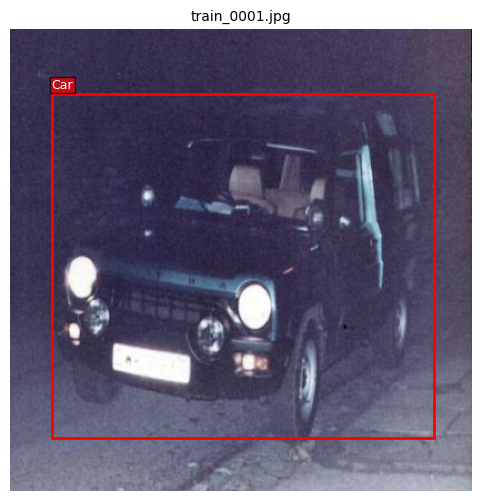

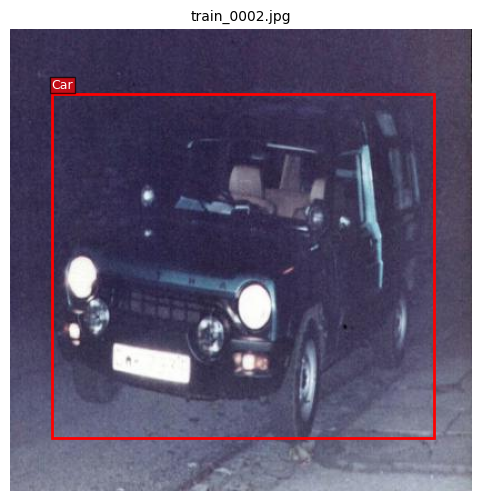

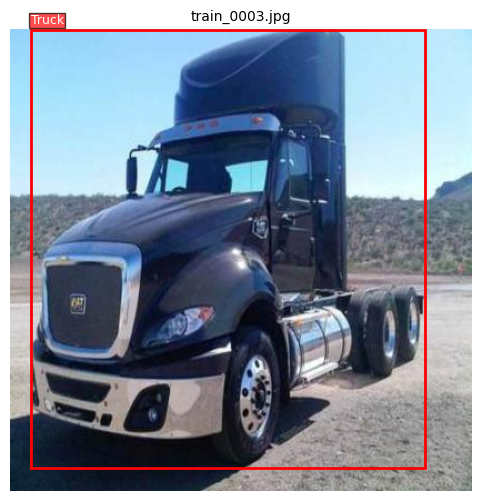

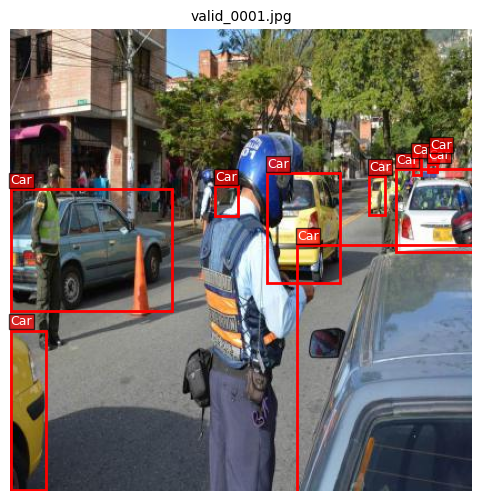

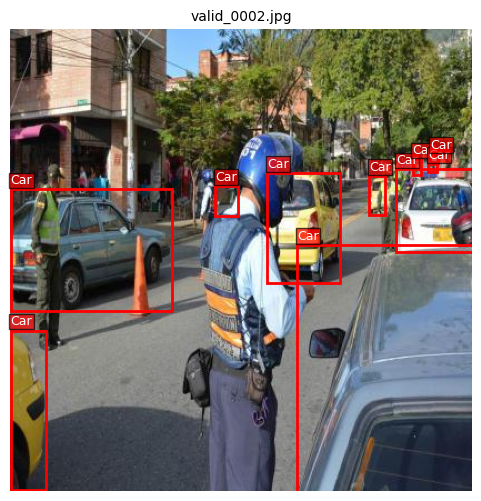

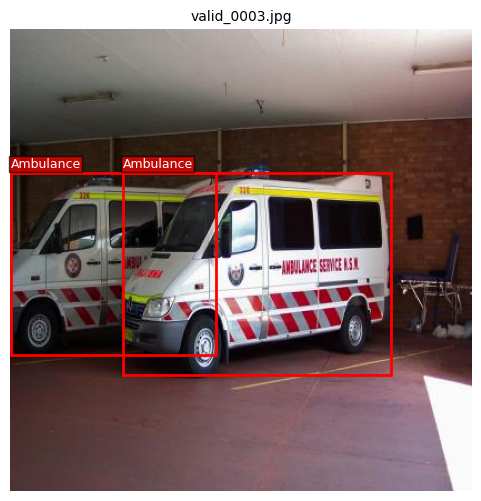

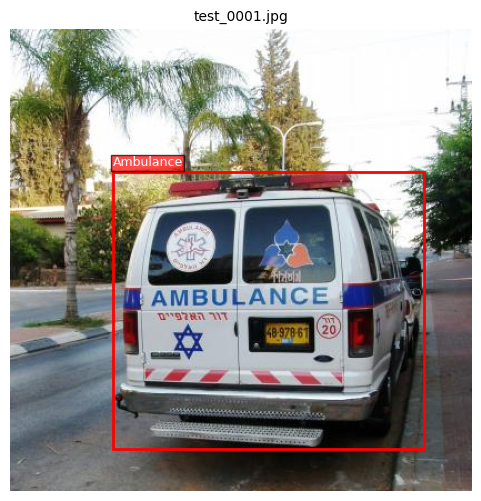

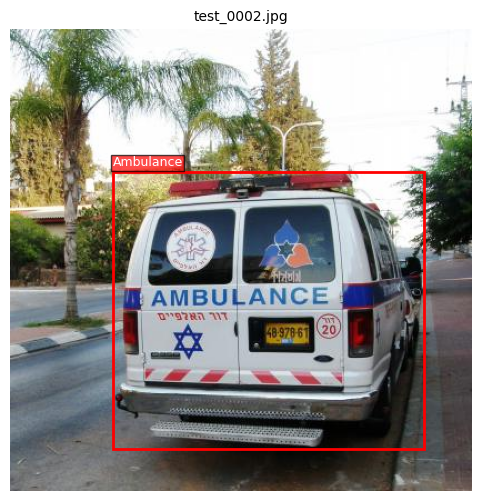

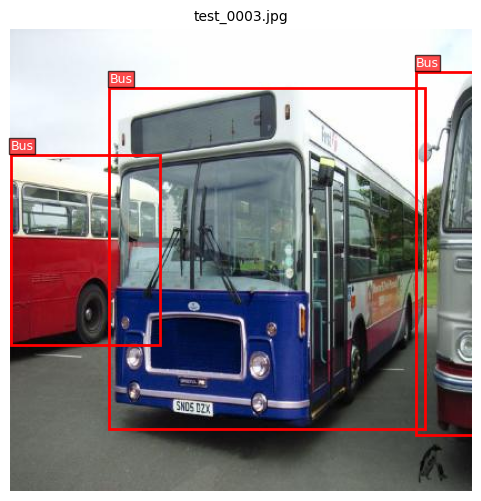

In [8]:
def show_image_with_boxes(img_path, lbl_path):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(mpimg.imread(img_path))

    with open(lbl_path, "r") as f:
        for line in f:
            cls_id, cx, cy, w, h = line.strip().split()
            cx, cy, w, h = float(cx), float(cy), float(w), float(h)
            x1 = (cx - w / 2) * IMG_W
            y1 = (cy - h / 2) * IMG_H

            rect = patches.Rectangle((x1, y1), w * IMG_W, h * IMG_H,
                                     linewidth=2, edgecolor="red", facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, CLASS_NAMES[int(cls_id)], color="white", fontsize=9,
                    bbox=dict(facecolor="red", alpha=0.7, pad=1))

    ax.set_title(os.path.basename(img_path), fontsize=10)
    ax.axis("off")
    plt.show()


# Show first 3 from each split
for split in split_names:
    img_dir = os.path.join(dataset_root, split, "images")
    lbl_dir = os.path.join(dataset_root, split, "labels")

    for img_name in sorted(os.listdir(img_dir))[:3]:
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, img_name.replace(".jpg", ".txt"))
        show_image_with_boxes(img_path, lbl_path)

In [9]:
import hashlib

for split in split_names:
    img_dir = os.path.join(dataset_root, split, "images")
    
    hash_to_files = {}
    for f in sorted(os.listdir(img_dir)):
        with open(os.path.join(img_dir, f), "rb") as img:
            h = hashlib.md5(img.read()).hexdigest()
        hash_to_files.setdefault(h, []).append(f)
    
    dupes = {h: files for h, files in hash_to_files.items() if len(files) > 1}
    print(f"{split}: {len(dupes)} sets of identical images")
    for h, files in list(dupes.items())[:3]:
        print(f"  {files}")

train: 439 sets of identical images
  ['train_0001.jpg', 'train_0002.jpg']
  ['train_0003.jpg', 'train_0004.jpg']
  ['train_0005.jpg', 'train_0006.jpg']
valid: 125 sets of identical images
  ['valid_0001.jpg', 'valid_0002.jpg']
  ['valid_0003.jpg', 'valid_0004.jpg']
  ['valid_0005.jpg', 'valid_0006.jpg']
test: 63 sets of identical images
  ['test_0001.jpg', 'test_0002.jpg']
  ['test_0003.jpg', 'test_0004.jpg']
  ['test_0005.jpg', 'test_0006.jpg']


### Remove Dataset

In [10]:
shutil.rmtree(dataset_root, ignore_errors=True)
print("Removed data locally")

shutil.rmtree(cache_path, ignore_errors=True)
print("Removed data from cache")

Removed data locally
Removed data from cache
